In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd

"""
    Load and preprocess data from a given file path.

    Args:
        file_path (str): The path to the CSV file containing the data.

    Returns:
        pd.DataFrame: Cleaned and preprocessed dataset."""

# Define file paths
combined_data_path = '/content/drive/MyDrive/Combined_Data[1].csv'
mental_health_data_path = '/content/drive/MyDrive/Mental_Health_Dataset[2].csv'

# Load the datasets
combined_data = pd.read_csv(combined_data_path)
mental_health_data = pd.read_csv(mental_health_data_path)

# Add a unique index column
combined_data['id'] = combined_data.index
mental_health_data['id'] = mental_health_data.index

# Merge datasets on 'id'
merged_data = pd.merge(combined_data, mental_health_data, how='left', on='id')

# Save the merged dataset
merged_data.to_csv('dataset.csv', index=False)
print("Left join completed and saved as 'dataset.csv'")


Left join completed and saved as 'dataset.csv'


In [3]:
# Load the newly created dataset
new_data = pd.read_csv('dataset.csv')
print(new_data.head())


   Unnamed: 0                                          statement   status  id  \
0           0                                         oh my gosh  Anxiety   0   
1           1  trouble sleeping, confused mind, restless hear...  Anxiety   1   
2           2  All wrong, back off dear, forward doubt. Stay ...  Anxiety   2   
3           3  I've shifted my focus to something else but I'...  Anxiety   3   
4           4  I'm restless and restless, it's been a month n...  Anxiety   4   

             Timestamp  Gender        Country Occupation self_employed  \
0  2014-08-27 11:29:31  Female  United States  Corporate           NaN   
1  2014-08-27 11:31:50  Female  United States  Corporate           NaN   
2  2014-08-27 11:32:39  Female  United States  Corporate           NaN   
3  2014-08-27 11:37:59  Female  United States  Corporate            No   
4  2014-08-27 11:43:36  Female  United States  Corporate            No   

  family_history  ... Days_Indoors Growing_Stress Changes_Habits  \


In [4]:
# Drop irrelevant columns
new_data.drop(['Unnamed: 0', 'id'], axis=1, inplace=True)

# Convert 'Timestamp' to datetime format
new_data['Timestamp'] = pd.to_datetime(new_data['Timestamp'])

# Fill missing values
new_data['statement'].fillna('No statement provided', inplace=True)
new_data['self_employed'].fillna(new_data['self_employed'].mode()[0], inplace=True)

# Remove duplicates
new_data.drop_duplicates(inplace=True)

# Check for remaining missing values
print("Missing values after preprocessing:\n", new_data.isnull().sum())

# Save cleaned data
new_data.to_csv('cleaned_dataset.csv', index=False)
print("Data preprocessing completed!")


<ipython-input-4-c998ad2cac24>:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  new_data['statement'].fillna('No statement provided', inplace=True)
<ipython-input-4-c998ad2cac24>:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace

Missing values after preprocessing:
 statement                  0
status                     0
Timestamp                  0
Gender                     0
Country                    0
Occupation                 0
self_employed              0
family_history             0
treatment                  0
Days_Indoors               0
Growing_Stress             0
Changes_Habits             0
Mental_Health_History      0
Mood_Swings                0
Coping_Struggles           0
Work_Interest              0
Social_Weakness            0
mental_health_interview    0
care_options               0
dtype: int64
Data preprocessing completed!


In [5]:
# Load the cleaned dataset
df = pd.read_csv("cleaned_dataset.csv")

 """
    Train and evaluate Naive Bayes, SVM, and MLP models on the dataset.

    Args:
        df (pd.DataFrame): The cleaned dataset to train models on.

    Returns:
        dict: A dictionary containing trained models and evaluation metrics.
    """

# Define feature columns and target column
feature_columns = [
    'Gender', 'Country', 'Occupation', 'self_employed', 'family_history',
    'treatment', 'Days_Indoors', 'Growing_Stress', 'Changes_Habits',
    'Mental_Health_History', 'Mood_Swings', 'Coping_Struggles',
    'Work_Interest', 'Social_Weakness', 'mental_health_interview'
]
target_column = 'status'

# One-hot encode categorical features
X = pd.get_dummies(df[feature_columns], drop_first=True)

# Encode target variable
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df[target_column])

# Split data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=56)


<ipython-input-6-88de4d429ea5>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_counts.index, y=gender_counts.values, palette="viridis")


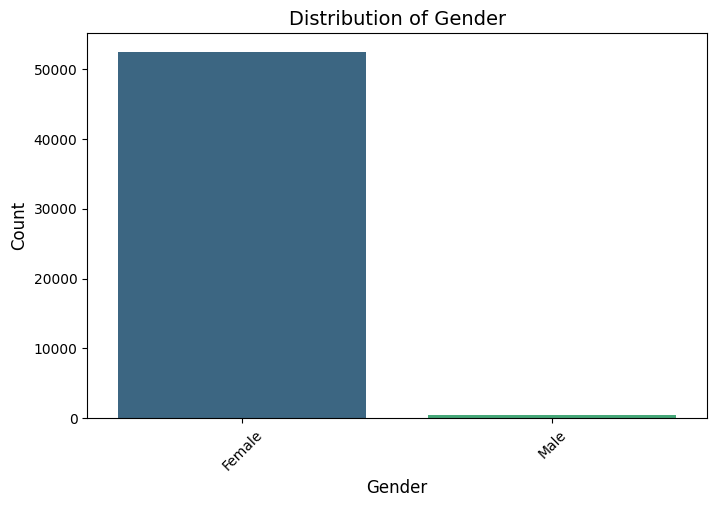

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Bar Graph: Distribution of Gender
plt.figure(figsize=(8, 5))
gender_counts = df['Gender'].value_counts()
sns.barplot(x=gender_counts.index, y=gender_counts.values, palette="viridis")
plt.title("Distribution of Gender", fontsize=14)
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45)
plt.show()








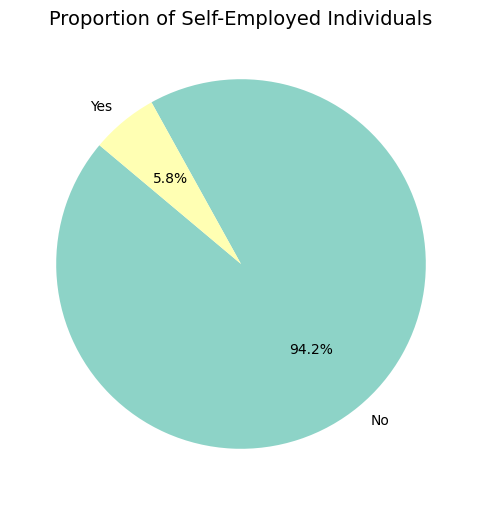

In [7]:
# Pie Chart: Proportion of self_employed
plt.figure(figsize=(6, 6))
self_employed_counts = df['self_employed'].value_counts()
plt.pie(self_employed_counts, labels=self_employed_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("Set3"))
plt.title("Proportion of Self-Employed Individuals", fontsize=14)
plt.show()

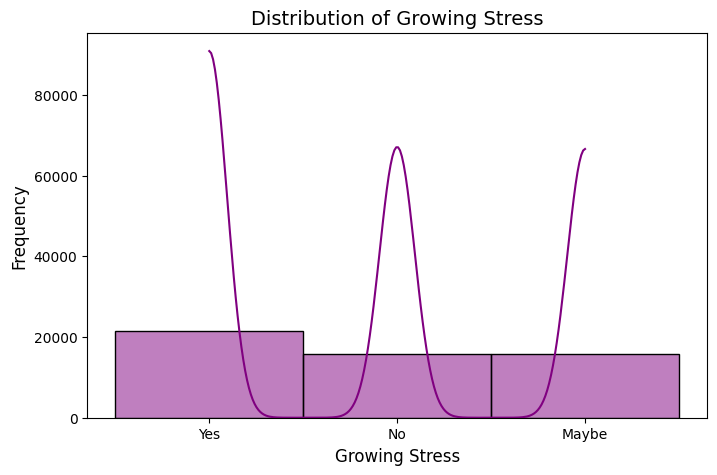

In [8]:

# Histogram: Distribution of Growing Stress
plt.figure(figsize=(8, 5))
sns.histplot(df['Growing_Stress'], bins=10, kde=True, color="purple")
plt.title("Distribution of Growing Stress", fontsize=14)
plt.xlabel("Growing Stress", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()

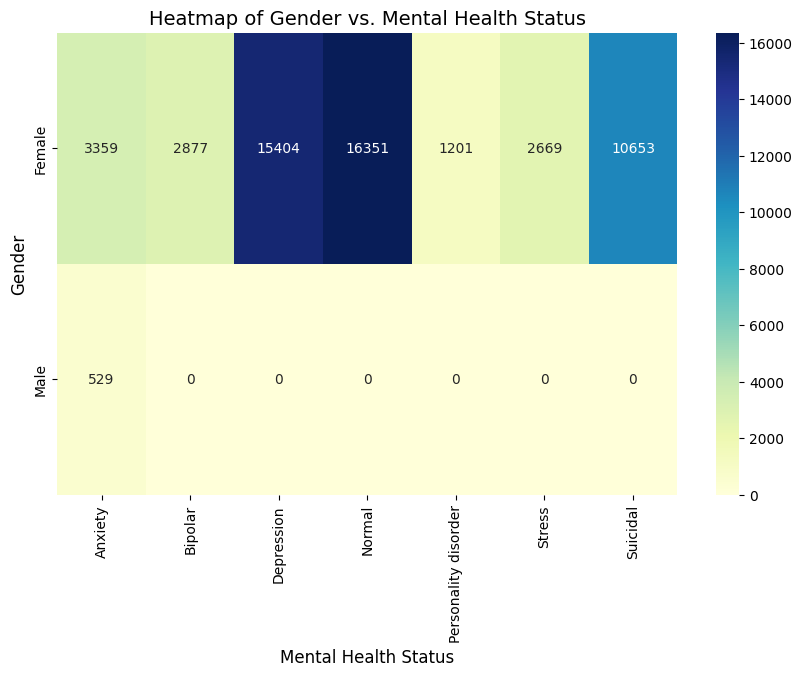

In [9]:
#Heatmap: Categorical Feature Relationships between gender and mental health status
crosstab = pd.crosstab(df['Gender'], df['status'])
plt.figure(figsize=(10, 6))
sns.heatmap(crosstab, annot=True, cmap='YlGnBu', fmt='d')
plt.title("Heatmap of Gender vs. Mental Health Status", fontsize=14)
plt.xlabel("Mental Health Status", fontsize=12)
plt.ylabel("Gender", fontsize=12)
plt.show()



<ipython-input-10-eb7c3d26a11c>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='status', y='Mood_Swings', palette='viridis')


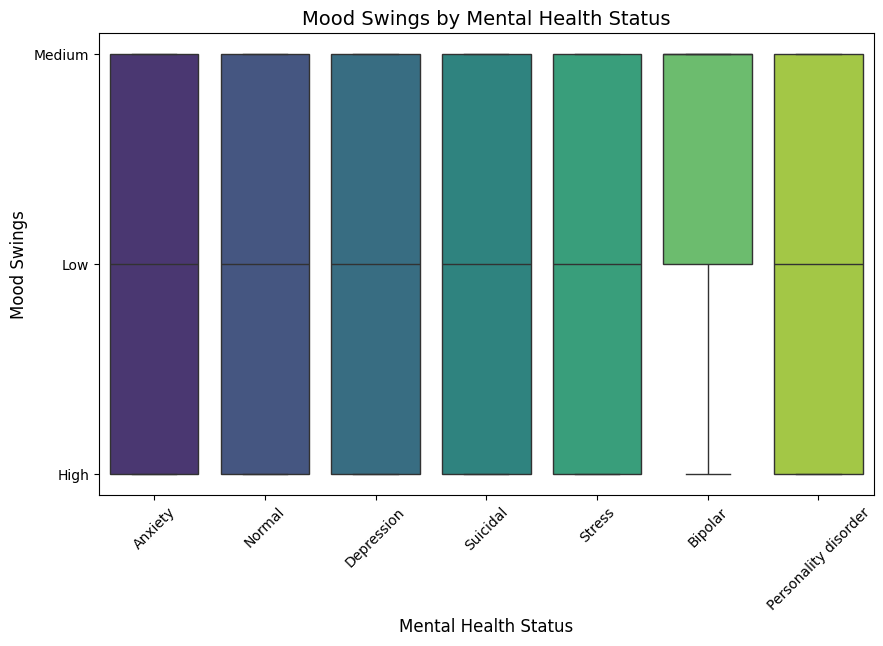

In [10]:
#Box Plot: Mood Swings by Mental Health Status
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='status', y='Mood_Swings', palette='viridis')
plt.title("Mood Swings by Mental Health Status", fontsize=14)
plt.xlabel("Mental Health Status", fontsize=12)
plt.ylabel("Mood Swings", fontsize=12)
plt.xticks(rotation=45)
plt.show()


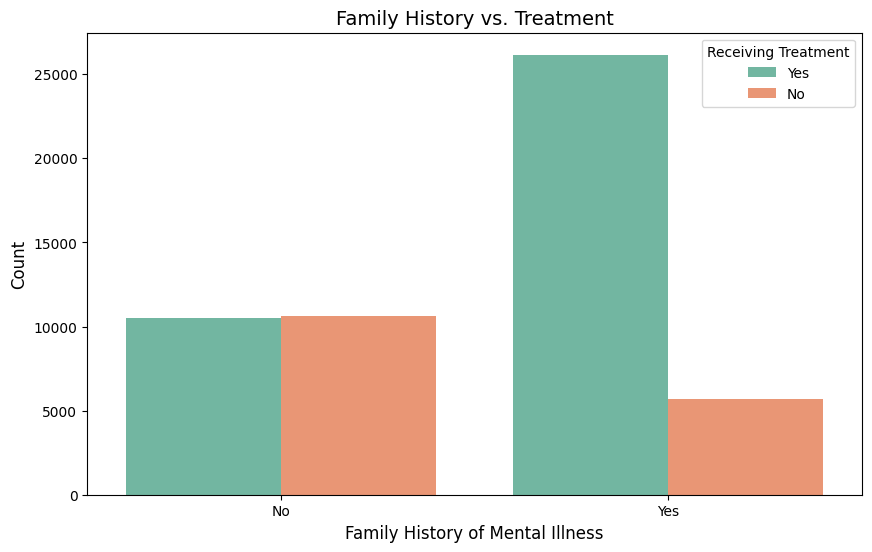

In [11]:
# Bar Plot: Family History vs. Treatment
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='family_history', hue='treatment', palette='Set2')
plt.title("Family History vs. Treatment", fontsize=14)
plt.xlabel("Family History of Mental Illness", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(title="Receiving Treatment")
plt.show()


Naive Bayes - Accuracy: 0.1058


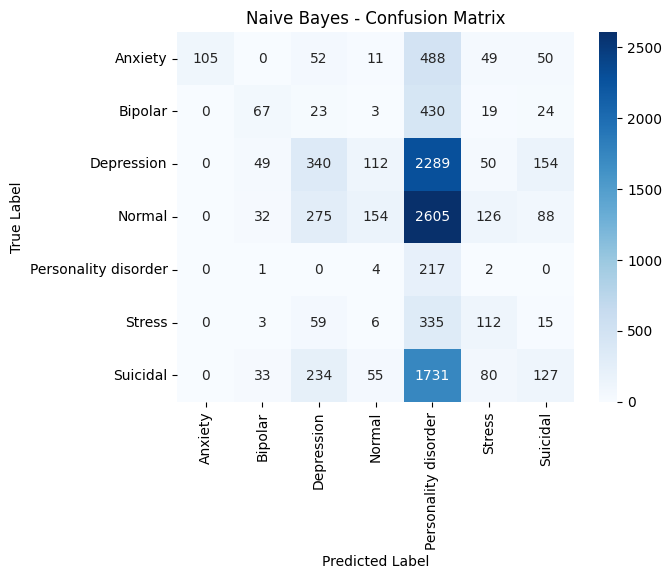

Naive Bayes - Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.14      0.24       755
           1       0.36      0.12      0.18       566
           2       0.35      0.11      0.17      2994
           3       0.45      0.05      0.08      3280
           4       0.03      0.97      0.05       224
           5       0.26      0.21      0.23       530
           6       0.28      0.06      0.09      2260

    accuracy                           0.11     10609
   macro avg       0.39      0.24      0.15     10609
weighted avg       0.40      0.11      0.13     10609

Naive Bayes - AUC Score (OvR): 0.6102


In [12]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
# Naive Bayes Model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

# Accuracy Score
nb_accuracy = accuracy_score(y_test, y_pred_nb)
print(f"Naive Bayes - Accuracy: {nb_accuracy:.4f}")

# Confusion Matrix
conf_matrix_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(conf_matrix_nb, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Naive Bayes - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Classification Report
print("Naive Bayes - Classification Report:\n", classification_report(y_test, y_pred_nb))

# ROC AUC Score
y_prob_nb = nb_model.predict_proba(X_test)
auc_score_nb = roc_auc_score(y_test, y_prob_nb, multi_class='ovr')
print(f"Naive Bayes - AUC Score (OvR): {auc_score_nb:.4f}")


SVM - Accuracy: 0.3611


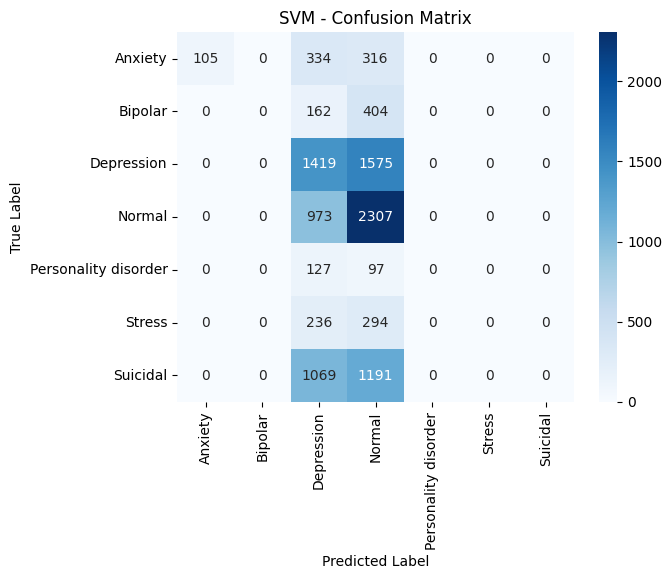

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


SVM - Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.14      0.24       755
           1       0.00      0.00      0.00       566
           2       0.33      0.47      0.39      2994
           3       0.37      0.70      0.49      3280
           4       0.00      0.00      0.00       224
           5       0.00      0.00      0.00       530
           6       0.00      0.00      0.00      2260

    accuracy                           0.36     10609
   macro avg       0.24      0.19      0.16     10609
weighted avg       0.28      0.36      0.28     10609

SVM - AUC Score (OvR): 0.7289


In [13]:
from sklearn.svm import SVC

# SVM Model
svm_model = SVC(kernel='linear', probability=True, random_state=56)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

# Accuracy Score
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print(f"SVM - Accuracy: {svm_accuracy:.4f}")

# Confusion Matrix
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(conf_matrix_svm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("SVM - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Classification Report
print("SVM - Classification Report:\n", classification_report(y_test, y_pred_svm))

# ROC AUC Score
y_prob_svm = svm_model.predict_proba(X_test)
auc_score_svm = roc_auc_score(y_test, y_prob_svm, multi_class='ovr')
print(f"SVM - AUC Score (OvR): {auc_score_svm:.4f}")


MLP - Cross-validated Accuracy: 0.7621, Test Accuracy: 0.7503
MLP - Accuracy: 0.7503


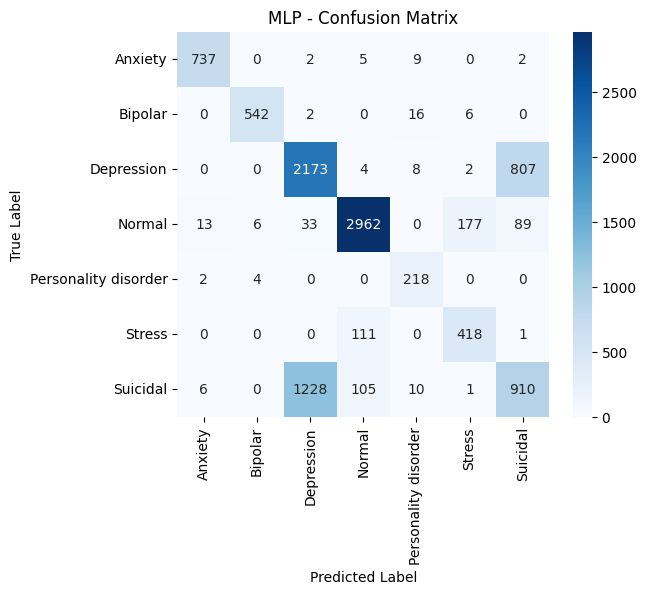

MLP - Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.97       755
           1       0.98      0.96      0.97       566
           2       0.63      0.73      0.68      2994
           3       0.93      0.90      0.92      3280
           4       0.84      0.97      0.90       224
           5       0.69      0.79      0.74       530
           6       0.50      0.40      0.45      2260

    accuracy                           0.75     10609
   macro avg       0.79      0.82      0.80     10609
weighted avg       0.75      0.75      0.75     10609

MLP - AUC Score (OvR): 0.9654


In [14]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
# Initialize MLP model
mlp_model = MLPClassifier(hidden_layer_sizes=(50, 25), max_iter=500, random_state=56)

# Train the model and cross-validate
cv_scores = cross_val_score(mlp_model, X_train, y_train, cv=5, scoring='accuracy')
mlp_model.fit(X_train, y_train)
y_pred = mlp_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

# Print accuracy results
print(f"MLP - Cross-validated Accuracy: {cv_scores.mean():.4f}, Test Accuracy: {test_accuracy:.4f}")

# Make Predictions
y_pred_mlp = mlp_model.predict(X_test)

# Accuracy Score
mlp_accuracy = accuracy_score(y_test, y_pred_mlp)
print(f"MLP - Accuracy: {mlp_accuracy:.4f}")

# Confusion Matrix
conf_matrix_mlp = confusion_matrix(y_test, y_pred_mlp)

# Confusion Matrix Plot
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_mlp, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("MLP - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Classification Report
print("MLP - Classification Report:\n", classification_report(y_test, y_pred_mlp))

# ROC AUC Score
y_prob_mlp = mlp_model.predict_proba(X_test)

# Calculate AUC score for multiclass (One-vs-Rest approach)
auc_score_mlp = roc_auc_score(y_test, y_prob_mlp, multi_class='ovr')
print(f"MLP - AUC Score (OvR): {auc_score_mlp:.4f}")


In [ ]:
import joblib

"""
    Save trained models and the label encoder to disk.

    Args:
        models (dict): Dictionary containing trained models.
        label_encoder (LabelEncoder): Fitted label encoder for the target variable.
    """

# Save the model and label encoder
joblib.dump(mlp_model, 'mlp_model.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')


"""
    Collect user input for mental health assessment.

    Returns:
        pd.DataFrame: User input data formatted as a DataFrame.
    """

# Interactive functions
def get_user_input():
    print("\nPlease answer the following questions honestly to help us assess your mental health status.")
    gender = input("What is your gender (Male/Female/Other)? ")
    country = input("Which country are you from? ")
    occupation = input("What is your occupation? ")
    self_employed = input("Are you self-employed (Yes/No)? ")
    family_history = input("Do you have a family history of mental illness (Yes/No)? ")
    treatment = input("Are you currently receiving treatment for mental health issues (Yes/No)? ")
    days_indoors = int(input("How many days per week do you stay indoors on average? "))
    growing_stress = input("Are you experiencing growing stress (Yes/No)? ")
    changes_habits = input("Have you experienced any changes in your habits (Yes/No)? ")
    mental_health_history = input("Do you have a history of mental health issues (Yes/No)? ")
    mood_swings = input("Are you experiencing mood swings (Yes/No)? ")
    coping_struggles = input("Are you having difficulty coping with life challenges (Yes/No)? ")
    work_interest = input("Are you losing interest in work (Yes/No)? ")
    social_weakness = input("Do you feel socially withdrawn (Yes/No)? ")
    mental_health_interview = input("Did you ever attend a mental health interview (Yes/No)? ")

    user_input = pd.DataFrame({
        'Gender': [gender],
        'Country': [country],
        'Occupation': [occupation],
        'self_employed': [self_employed],
        'family_history': [family_history],
        'treatment': [treatment],
        'Days_Indoors': [days_indoors],
        'Growing_Stress': [growing_stress],
        'Changes_Habits': [changes_habits],
        'Mental_Health_History': [mental_health_history],
        'Mood_Swings': [mood_swings],
        'Coping_Struggles': [coping_struggles],
        'Work_Interest': [work_interest],
        'Social_Weakness': [social_weakness],
        'mental_health_interview': [mental_health_interview]
    })

    return user_input

def preprocess_input(user_input, training_columns):
    # One-hot encode user input and align it with training data
    user_input_encoded = pd.get_dummies(user_input, drop_first=True)
    for col in training_columns:
        if col not in user_input_encoded.columns:
            user_input_encoded[col] = 0  # Add missing columns as zeros
    return user_input_encoded[training_columns]

def predict_status(model, label_encoder, processed_input):
    prediction = model.predict(processed_input)
    return label_encoder.inverse_transform(prediction)[0]

def interactive_demo():
    # Load the trained model and label encoder
    model = joblib.load('mlp_model.pkl')
    label_encoder = joblib.load('label_encoder.pkl')

    while True:
        # Step 1: Get user input
        user_input = get_user_input()

        # Step 2: Preprocess the input
        training_columns = pd.get_dummies(X, drop_first=True).columns  # Match model's training columns
        processed_input = preprocess_input(user_input, training_columns)

        # Step 3: Make prediction using the model
        predicted_status = predict_status(model, label_encoder, processed_input)

        # Step 4: Display the result
        print(f"\nBased on your responses, your predicted mental health status is: {predicted_status}")
        messages = {
            'depression': "It seems like you might be experiencing depression. Please consider speaking to a healthcare professional for support.",
            'anxiety': "It seems like you might be experiencing anxiety. Please take steps to manage stress, and consider seeking help.",
            'normal': "It seems like you're not showing signs of a mental health disorder, but regular self-care is still important.",
            'suicidal': "It seems like you're experiencing severe mental health challenges. Please seek immediate support from professionals or helplines.",
            'stress': "It seems like you're experiencing stress. Make sure to take breaks and practice relaxation techniques.",
            'bipolar': "It seems like you're experiencing symptoms of bipolar disorder. Please seek guidance from a specialist.",
            'personality disorder': "It seems like you might have traits related to a personality disorder. Consider consulting a therapist for an accurate assessment."
        }
        print(messages.get(predicted_status.lower(), "Please consult with a healthcare professional for further assessment."))

        # Ask if the user wants to continue
        repeat = input("\nDo you want to assess another person? (yes/no): ").strip().lower()
        if repeat != 'yes':
            print("Thank you for using the mental health assessment tool. Take care!")
            break


In [ ]:


# Run the interactive demo
interactive_demo()


Please answer the following questions honestly to help us assess your mental health status.

Based on your responses, your predicted mental health status is: Normal
It seems like you're not showing signs of a mental health disorder, but regular self-care is still important.

Please answer the following questions honestly to help us assess your mental health status.
